In [3]:
import re
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

sys.path.append("../utils/py")
import miniramses as ram

plt.rcParams["font.family"] = "serif"
plt.rcParams["figure.dpi"] = 180
plt.rcParams.update({
    "font.size": 14,
    "legend.fontsize": 16,
})


import sys

# Try both repo-root and analyze/ working directories.
for cand in [Path("utils/py"), Path("../utils/py")]:
    if cand.exists() and str(cand.resolve()) not in sys.path:
        sys.path.append(str(cand.resolve()))

import miniramses as ram

plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.size"] = 11

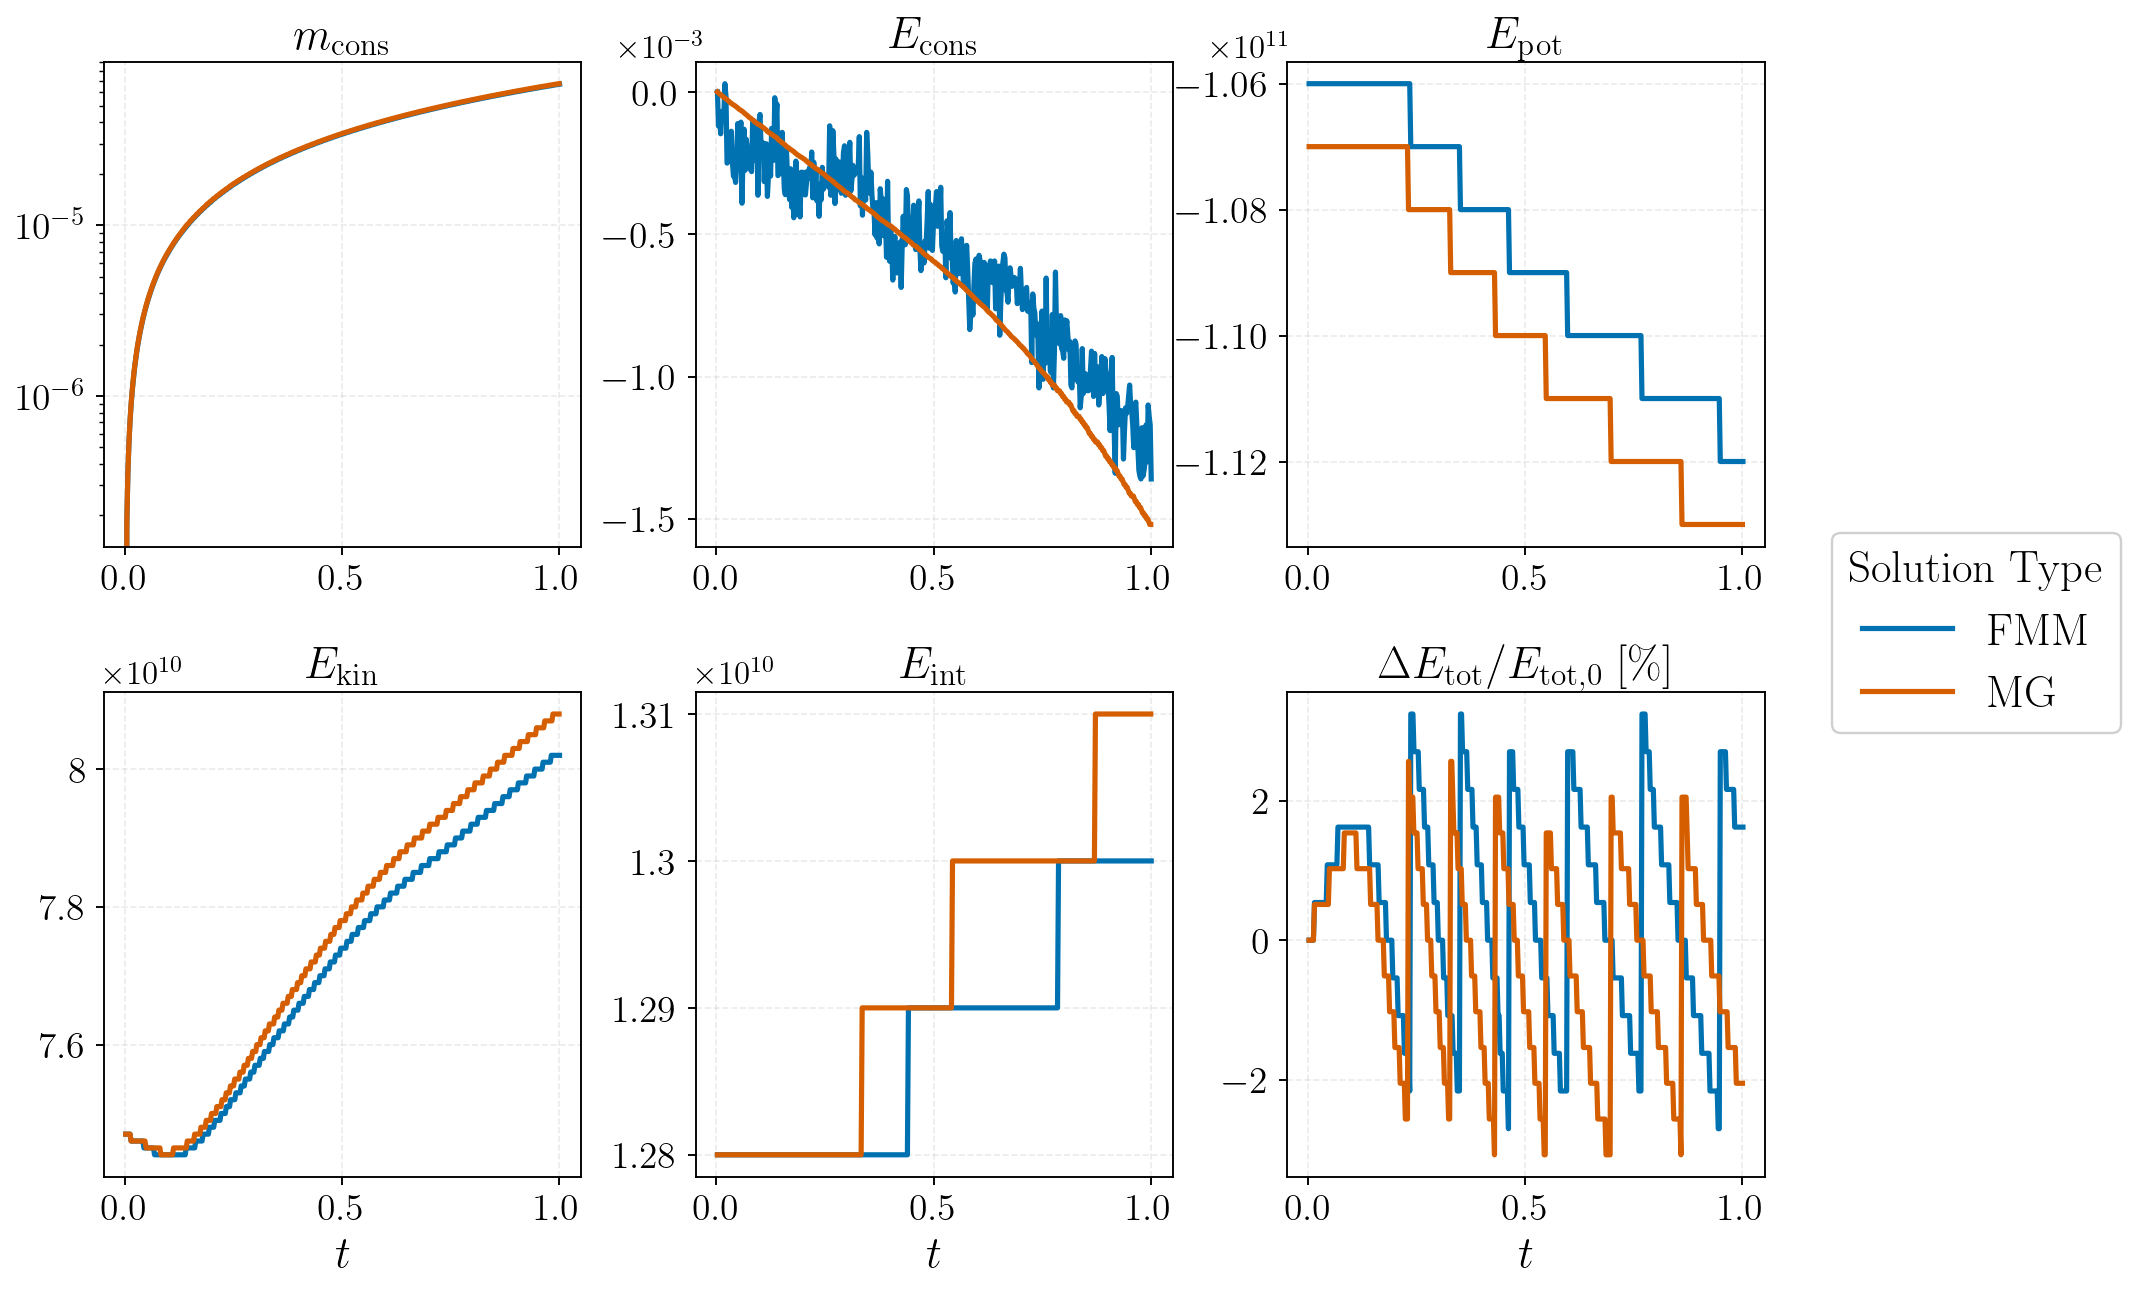

In [4]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, MaxNLocator, FuncFormatter

# -----------------------------
# Style
# -----------------------------
plt.rcParams["font.family"] = "serif"
plt.rcParams["figure.dpi"] = 170
plt.rcParams["text.usetex"] = True
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"
plt.rcParams.update(
    {
        "font.size": 16,
        "axes.labelsize": 19,
        "axes.titlesize": 19,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 19,
    }
)

def parse_file(filename):
    main_pattern = re.compile(
        r"Main step=\s*(\d+)\s+"
        r"mcons=\s*([-\d.E+]+)\s+"
        r"econs=\s*([-\d.E+]+)\s+"
        r"epot=\s*([-\d.E+]+)\s+"
        r"ekin=\s*([-\d.E+]+)\s+"
        r"eint=\s*([-\d.E+]+)"
    )
    time_pattern = re.compile(r"Fine step=\s*\d+\s+t=\s*([-\d.E+]+)")

    data = []
    current_time = np.nan

    with open(filename, "r") as f:
        for line in f:
            t_match = time_pattern.search(line)
            if t_match:
                current_time = float(t_match.group(1))

            m = main_pattern.search(line)
            if m:
                step, mcons, econs, epot, ekin, eint = m.groups()
                epot_f = float(epot)
                ekin_f = float(ekin)
                eint_f = float(eint)
                data.append(
                    {
                        "step": int(step),
                        "time": float(current_time),
                        "mcons": float(mcons),
                        "econs": float(econs),
                        "epot": epot_f,
                        "ekin": ekin_f,
                        "eint": eint_f,
                        "etot": epot_f + ekin_f + eint_f,
                    }
                )

    return pd.DataFrame(data).sort_values("step").reset_index(drop=True)

def apply_sci_multiplier_top_left(ax):
    fmt = ScalarFormatter(useMathText=True)
    fmt.set_scientific(True)
    fmt.set_powerlimits((0, 0))
    ax.yaxis.set_major_formatter(fmt)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    off = ax.yaxis.get_offset_text()
    off.set_size(14)
    off.set_ha("left")
    off.set_x(-0.16)
    off.set_y(1.01)

def apply_clean_energy_ticks(ax, scale=1.0e10):
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda y, _: f"{y/scale:.2f}".rstrip("0").rstrip("."))
    )
    ax.yaxis.get_offset_text().set_visible(False)
    ax.text(
        0.0, 1.01, rf"$\times 10^{{{int(np.log10(scale))}}}$",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=14
    )

# -----------------------------
# Load data
# -----------------------------
df_fmm = parse_file("/home/jl4415/mini-ramses/halo_test/halo_fmm/fmm_2707491.out")
df_mg  = parse_file("/home/jl4415/mini-ramses/halo_test/halo_mg/mg_2707491.out")

vars_list = ["mcons", "econs", "epot", "ekin", "eint", "etot"]
title_map = {
    "mcons": r"$m_{\mathrm{cons}}$",
    "econs": r"$E_{\mathrm{cons}}$",
    "epot": r"$E_{\mathrm{pot}}$",
    "ekin": r"$E_{\mathrm{kin}}$",
    "eint": r"$E_{\mathrm{int}}$",
    "etot": r"$\Delta E_{\mathrm{tot}} / E_{\mathrm{tot},0}\ [\%]$",
}

# Match amr_sphere mapping:
# FMM = blue, MG = orange
color_fmm = "#0072B2"
color_mg  = "#D55E00"

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(13.2, 8.0), constrained_layout=False)
fig.subplots_adjust(left=0.08, right=0.82, bottom=0.10, top=0.92, wspace=0.24, hspace=0.30)
axes = axes.flatten()

for i, var in enumerate(vars_list):
    ax = axes[i]

    if var == "etot":
        # normalize and convert to percent
        y_fmm = 100.0 * (df_fmm[var] - df_fmm[var].iloc[0]) / df_fmm[var].iloc[0]
        y_mg  = 100.0 * (df_mg[var]  - df_mg[var].iloc[0])  / df_mg[var].iloc[0]
        ax.plot(df_fmm["time"], y_fmm, color=color_fmm, lw=2.2, ls="-", label="FMM")
        ax.plot(df_mg["time"],  y_mg,  color=color_mg,  lw=2.2, ls="-", label="MG")
    else:
        ax.plot(df_fmm["time"], df_fmm[var], color=color_fmm, lw=2.2, ls="-", label="FMM")
        ax.plot(df_mg["time"],  df_mg[var],  color=color_mg,  lw=2.2, ls="-", label="MG")

    ax.set_title(title_map[var], pad=6)

    # remove x-label on first row only
    if i >= 3:
        ax.set_xlabel(r"$t$")
    else:
        ax.set_xlabel("")

    ax.grid(True, alpha=0.25, ls="--", lw=0.7)

    if var == "mcons":
        ax.set_yscale("log")
    elif var in ("ekin", "eint"):
        apply_clean_energy_ticks(ax, scale=1.0e10)
    elif var != "etot" and (df_fmm[var] > 0).all() and (df_mg[var] > 0).all():
        ax.set_yscale("log")
    else:
        apply_sci_multiplier_top_left(ax)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="center left",
    bbox_to_anchor=(0.84, 0.50),
    framealpha=0.92,
    title="Solution Type",
    title_fontsize=19,
)

out_path = Path("./fig/isolated_halo_diag.pdf")
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, dpi=250)
plt.show()


In [9]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, MaxNLocator, FuncFormatter

# -----------------------------
# Style
# -----------------------------
plt.rcParams["font.family"] = "serif"
plt.rcParams["figure.dpi"] = 170
plt.rcParams["text.usetex"] = True
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"
plt.rcParams.update(
    {
        "font.size": 16,
        "axes.labelsize": 19,
        "axes.titlesize": 19,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 19,
    }
)

def parse_file(filename):
    main_pattern = re.compile(
        r"Main step=\s*(\d+)\s+"
        r"mcons=\s*([-\d.E+]+)\s+"
        r"econs=\s*([-\d.E+]+)\s+"
        r"epot=\s*([-\d.E+]+)\s+"
        r"ekin=\s*([-\d.E+]+)\s+"
        r"eint=\s*([-\d.E+]+)"
    )
    time_pattern = re.compile(r"Fine step=\s*\d+\s+t=\s*([-\d.E+]+)")

    data = []
    current_time = np.nan

    with open(filename, "r") as f:
        for line in f:
            t_match = time_pattern.search(line)
            if t_match:
                current_time = float(t_match.group(1))

            m = main_pattern.search(line)
            if m:
                step, mcons, econs, epot, ekin, eint = m.groups()
                epot_f = float(epot)
                ekin_f = float(ekin)
                eint_f = float(eint)
                data.append(
                    {
                        "step": int(step),
                        "time": float(current_time),
                        "mcons": float(mcons),
                        "econs": float(econs),
                        "epot": epot_f,
                        "ekin": ekin_f,
                        "eint": eint_f,
                        "etot": epot_f + ekin_f + eint_f,
                    }
                )

    return pd.DataFrame(data).sort_values("step").reset_index(drop=True)

def apply_sci_multiplier_top_left(ax):
    fmt = ScalarFormatter(useMathText=True)
    fmt.set_scientific(True)
    fmt.set_powerlimits((0, 0))
    ax.yaxis.set_major_formatter(fmt)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    off = ax.yaxis.get_offset_text()
    off.set_size(14)
    off.set_ha("left")
    off.set_x(-0.16)
    off.set_y(1.01)

def apply_clean_energy_ticks(ax, scale=1.0e10):
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda y, _: f"{y/scale:.2f}".rstrip("0").rstrip("."))
    )
    ax.yaxis.get_offset_text().set_visible(False)
    ax.text(
        0.0, 1.01, rf"$\times 10^{{{int(np.log10(scale))}}}$",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=14
    )

# -----------------------------
# Load data
# -----------------------------
df_fmm = parse_file("/home/jl4415/mini-ramses/halo_test/halo_fmm/fmm_2707491.out")
df_mg  = parse_file("/home/jl4415/mini-ramses/halo_test/halo_mg/mg_2707491.out")

vars_list = ["mcons", "econs", "epot", "ekin", "eint", "etot"]

title_map = {
    "mcons": r"$m_{\mathrm{cons}}$",
    "econs": r"$E_{\mathrm{cons}}$",
    "epot": r"$\Delta E_{\mathrm{pot}} / E_{\mathrm{pot},0}\ [\%]$",
    "ekin": r"$\Delta E_{\mathrm{kin}} / E_{\mathrm{kin},0}\ [\%]$",
    "eint": r"$\Delta E_{\mathrm{int}} / E_{\mathrm{int},0}\ [\%]$",
    "etot": r"$\Delta E_{\mathrm{tot}} / E_{\mathrm{tot},0}\ [\%]$",
}

# FMM = blue, MG = orange
color_fmm = "#0072B2"
color_mg  = "#D55E00"

# Panels that should be plotted as relative drift
relative_vars = {"epot", "ekin", "eint", "etot"}



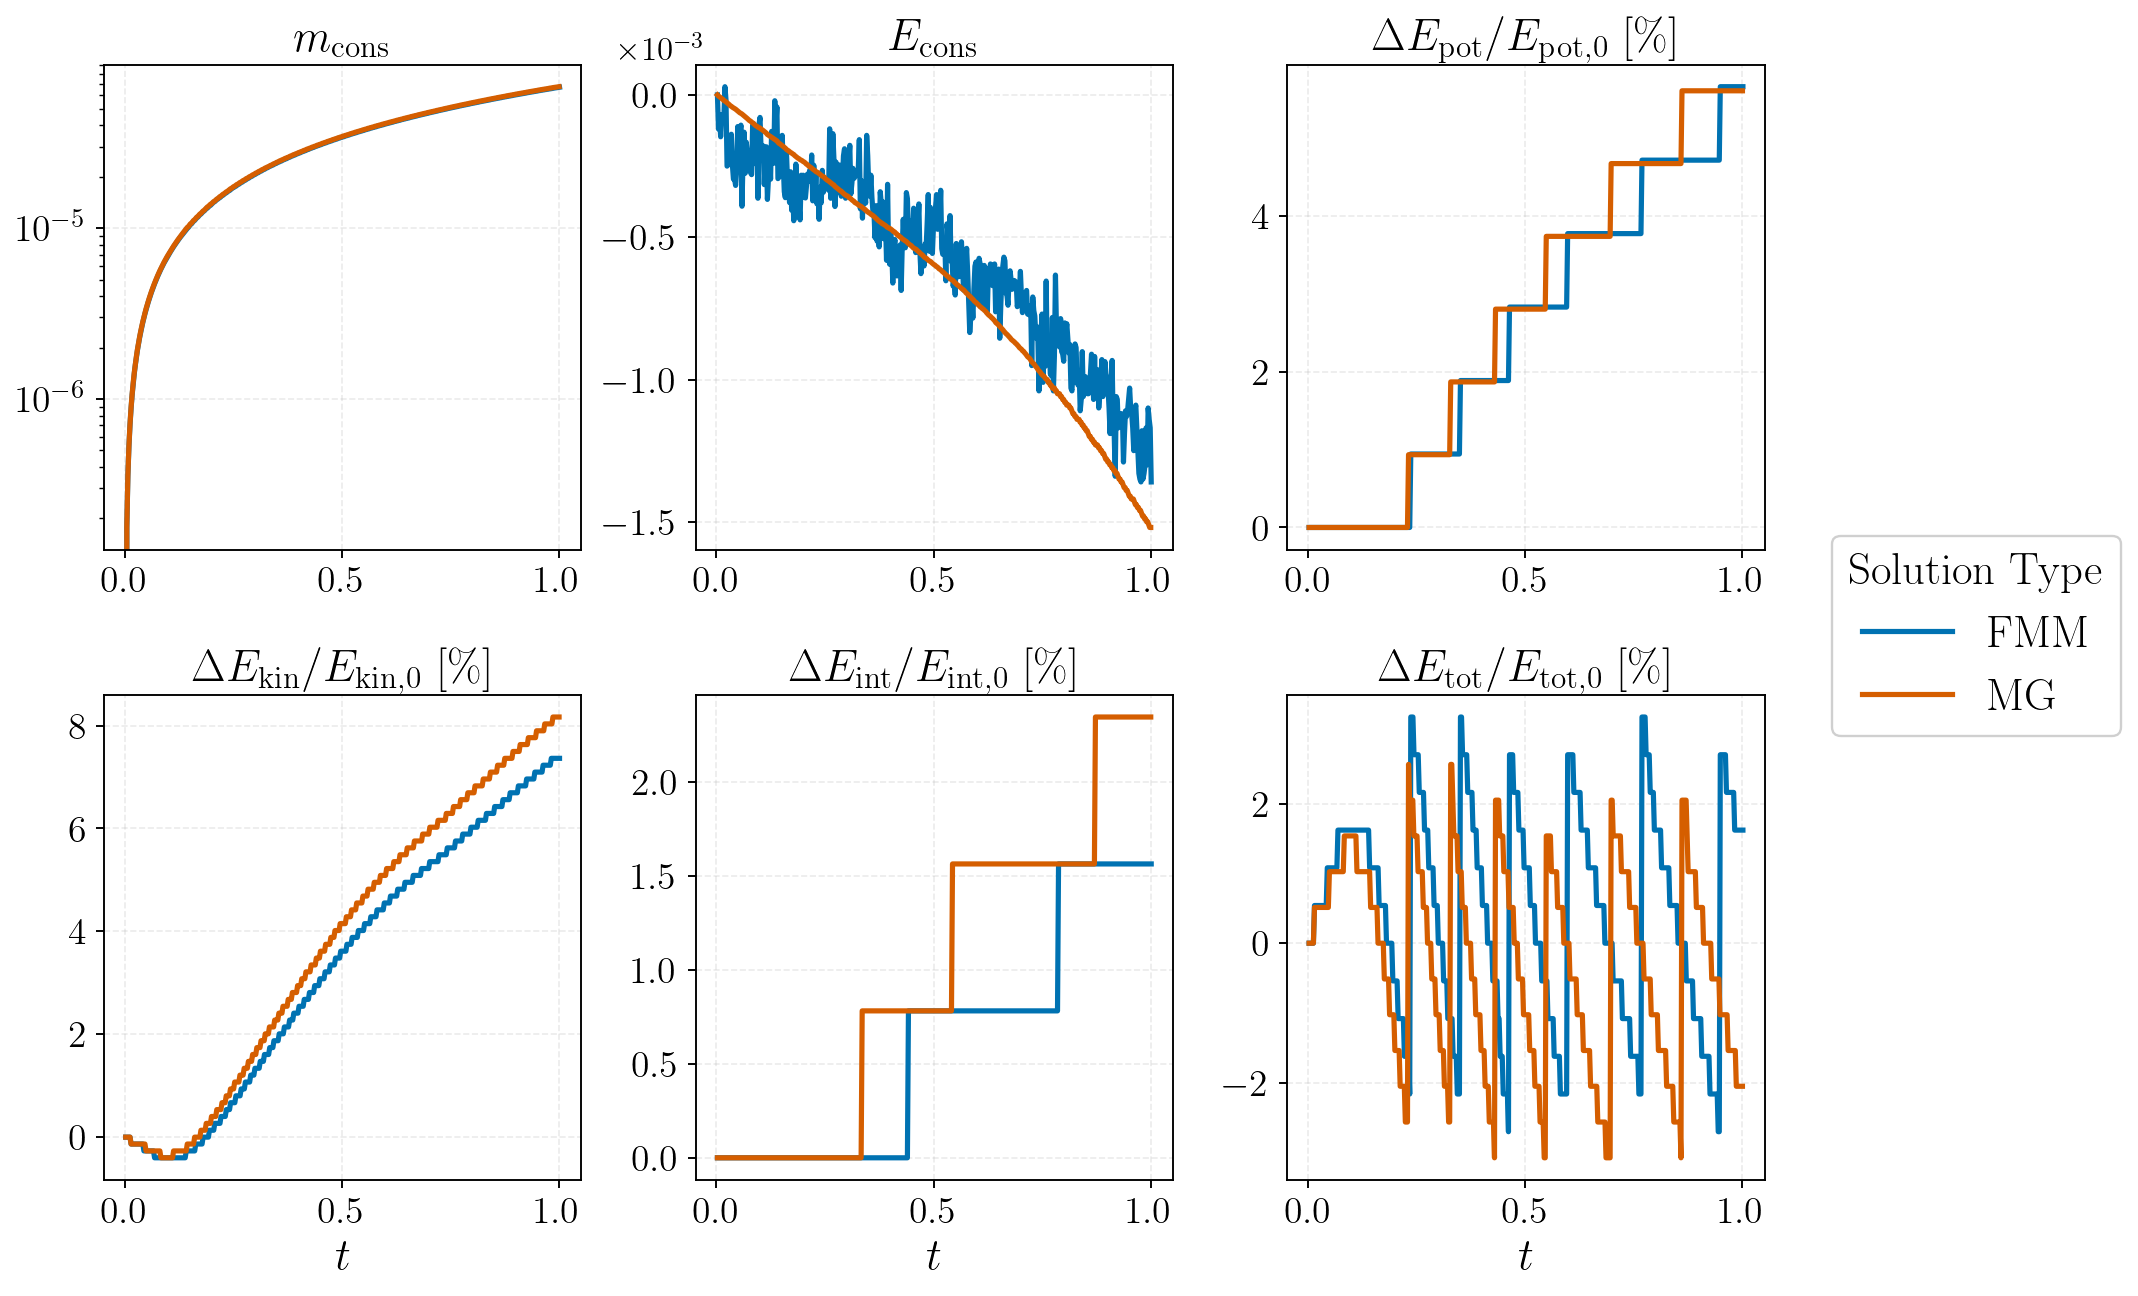

In [10]:
# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(13.2, 8.0), constrained_layout=False)
fig.subplots_adjust(left=0.08, right=0.82, bottom=0.10, top=0.92, wspace=0.24, hspace=0.30)
axes = axes.flatten()

for i, var in enumerate(vars_list):
    ax = axes[i]

    if var in relative_vars:
        y_fmm = 100.0 * (df_fmm[var] - df_fmm[var].iloc[0]) / df_fmm[var].iloc[0]
        y_mg  = 100.0 * (df_mg[var]  - df_mg[var].iloc[0])  / df_mg[var].iloc[0]

        ax.plot(df_fmm["time"], y_fmm, color=color_fmm, lw=2.2, ls="-", label="FMM")
        ax.plot(df_mg["time"],  y_mg,  color=color_mg,  lw=2.2, ls="-", label="MG")
    else:
        ax.plot(df_fmm["time"], df_fmm[var], color=color_fmm, lw=2.2, ls="-", label="FMM")
        ax.plot(df_mg["time"],  df_mg[var],  color=color_mg,  lw=2.2, ls="-", label="MG")

    ax.set_title(title_map[var], pad=6)

    if i >= 3:
        ax.set_xlabel(r"$t$")
    else:
        ax.set_xlabel("")

    ax.grid(True, alpha=0.25, ls="--", lw=0.7)

    # Axis formatting
    if var == "mcons":
        ax.set_yscale("log")
    elif var == "econs":
        if (df_fmm[var] > 0).all() and (df_mg[var] > 0).all():
            ax.set_yscale("log")
        else:
            apply_sci_multiplier_top_left(ax)
    else:
        # epot, ekin, eint, etot are now relative drifts in percent
        apply_sci_multiplier_top_left(ax)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="center left",
    bbox_to_anchor=(0.84, 0.50),
    framealpha=0.92,
    title="Solution Type",
    title_fontsize=19,
)

out_path = Path("./fig/isolated_halo_diag.pdf")
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, dpi=250)
plt.show()